In [ ]:
import os


if os.path.exists("archive (8).zip"):
    !unzip -q "archive (8).zip" -d neu_dataset
    print("Dataset extracted successfully!")
else:
    print("Error: 'archive (8).zip' not found. Please upload it to Colab first.")

Dataset extracted successfully!


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50, InceptionV3, EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt
import os

In [ ]:
train_dir = './neu_dataset/NEU-DET/train/images'
val_dir = './neu_dataset/NEU-DET/validation/images'

In [ ]:
BATCH_SIZE = 32
IMG_SIZE = (224, 224)

print("Loading training data...")
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode='rgb'
)

print("Loading validation data...")
val_dataset = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode='rgb'
)

class_names = train_dataset.class_names
num_classes = len(class_names)
print(f"Classes identified: {class_names}")

AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.prefetch(buffer_size=AUTOTUNE)

Loading training data...
Found 1440 files belonging to 6 classes.
Loading validation data...
Found 360 files belonging to 6 classes.
Classes identified: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']


In [ ]:
def build_model(base_model_class, model_name):
    print(f"\n--- Building {model_name} ---")

    inputs = tf.keras.Input(shape=IMG_SIZE + (3,))


    if model_name == "ResNet50":
        x = tf.keras.applications.resnet50.preprocess_input(inputs)
    elif model_name == "InceptionV3":
        x = tf.keras.applications.inception_v3.preprocess_input(inputs)
    elif model_name == "EfficientNet":
        x = inputs


    base_model = base_model_class(include_top=False, weights='imagenet')
    base_model.trainable = False

    x = base_model(x)


    x = GlobalAveragePooling2D()(x)
    x = Dense(128, activation='relu')(x)
    predictions = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=inputs, outputs=predictions)
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

In [ ]:
def train_and_plot(model, model_name, epochs=10):
    print(f"Training {model_name}...")
    history = model.fit(
        train_dataset,
        validation_data=val_dataset,
        epochs=epochs
    )

    loss, accuracy = model.evaluate(val_dataset)
    print(f"\n>>> {model_name} Final Validation Accuracy: {accuracy*100:.2f}% <<<\n")

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title(f'{model_name} Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f'{model_name} Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

    return history

In [ ]:
EPOCHS = 10


--- Building ResNet50 ---
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Training ResNet50...
Epoch 1/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 349s 8s/step - accuracy: 0.9424 - loss: 0.1881 - val_accuracy: 0.9722 - val_loss: 0.0709
Epoch 2/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 321s 7s/step - accuracy: 0.9986 - loss: 0.0048 - val_accuracy: 0.9750 - val_loss: 0.0823
Epoch 3/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 337s 7s/step - accuracy: 1.0000 - loss: 0.0025 - val_accuracy: 0.9583 - val_loss: 0.1325
Epoch 4/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 335s 7s/step - accuracy: 1.0000 - loss: 0.0012 - val_accuracy: 0.9889 - val_loss: 0.0405
Epoch 5/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 318s 7s/step - accuracy: 1.0000 - loss: 7.2062e-04 - val_accuracy: 0.9917 - val_loss: 0.0319
Epoch 6/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 335s 7s/step - accuracy: 1.0000 - loss: 5.3822e-04 - val_accuracy: 0.9917 - val_loss: 0.0394
Epoch 7/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 319s 7s/step - accuracy: 1.0000 - loss: 4.4899e-04 - val_accuracy: 0.9917 - val_loss: 0.0378


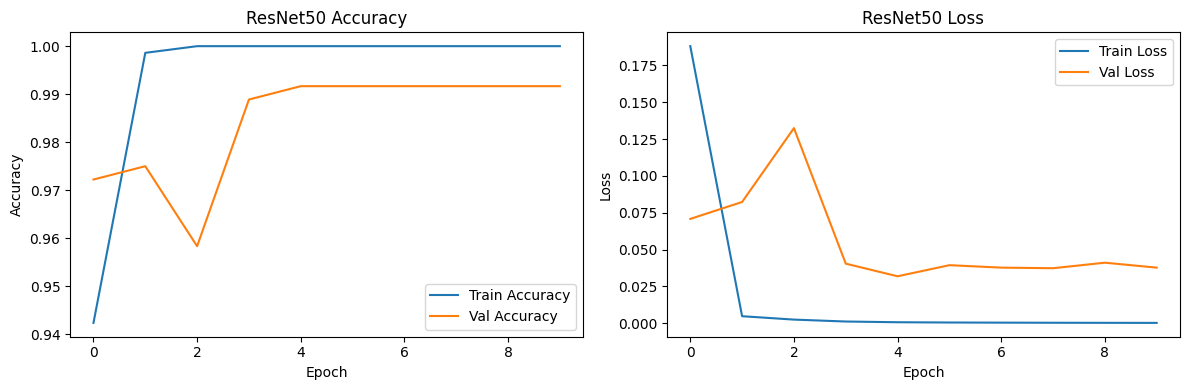

In [ ]:
resnet_model = build_model(ResNet50, "ResNet50")
train_and_plot(resnet_model, "ResNet50", epochs=EPOCHS)


--- Building InceptionV3 ---
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training InceptionV3...
Epoch 1/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 34s 365ms/step - accuracy: 0.9049 - loss: 0.2982 - val_accuracy: 0.9278 - val_loss: 0.2233
Epoch 2/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - accuracy: 0.9931 - loss: 0.0303 - val_accuracy: 0.9611 - val_loss: 0.0915
Epoch 3/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 77ms/step - accuracy: 0.9979 - loss: 0.0113 - val_accuracy: 0.9667 - val_loss: 0.0953
Epoch 4/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 78ms/step - accuracy: 1.0000 - loss: 0.0053 - val_accuracy: 0.9583 - val_loss: 0.0974
Epoch 5/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 81ms/step - accuracy: 1.0000 - loss: 0.0032 - val_accuracy: 0.9694 - val_loss: 0.0861
Epoch 6/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 79ms/step - accuracy: 1.0000 - loss: 0.0022 - val_accuracy: 0.9611 - val_loss: 0.0960
Epoch 7/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 79ms/step - accuracy: 1.0000 - loss: 0.0019 - val_accuracy: 0.9639 - val_loss: 0.0915
Epoc

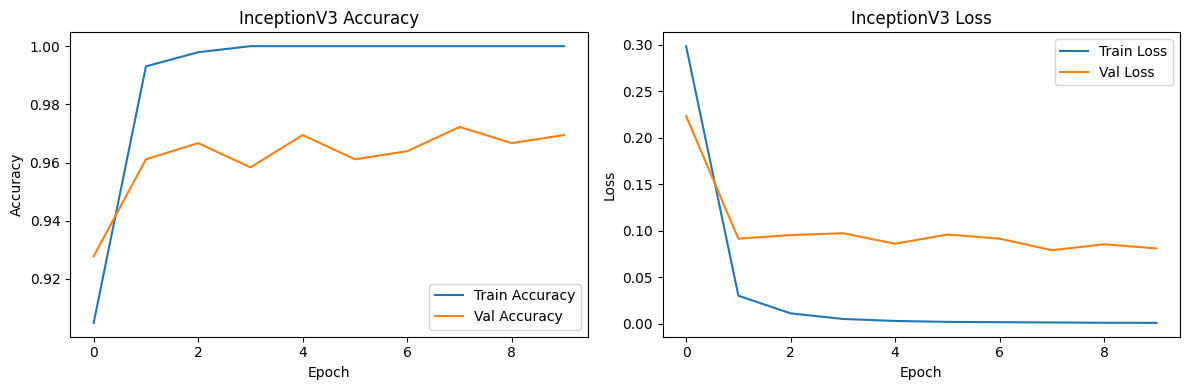

In [ ]:
inception_model = build_model(InceptionV3, "InceptionV3")
train_and_plot(inception_model, "InceptionV3", epochs=EPOCHS)


--- Building EfficientNet ---
Training EfficientNet...
Epoch 1/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 48s 450ms/step - accuracy: 0.9035 - loss: 0.4179 - val_accuracy: 0.9222 - val_loss: 0.2263
Epoch 2/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 0.9882 - loss: 0.0572 - val_accuracy: 0.9583 - val_loss: 0.1242
Epoch 3/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.9958 - loss: 0.0310 - val_accuracy: 0.9722 - val_loss: 0.0909
Epoch 4/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.9965 - loss: 0.0230 - val_accuracy: 0.9861 - val_loss: 0.0565
Epoch 5/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.9972 - loss: 0.0193 - val_accuracy: 0.9611 - val_loss: 0.0997
Epoch 6/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 1.0000 - loss: 0.0119 - val_accuracy: 0.9944 - val_loss: 0.0298
Epoch 7/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - accuracy: 0.9986 - loss: 0.0123 - val_accuracy: 0.9833 - val_loss: 0.0567
Epoch 8/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - 

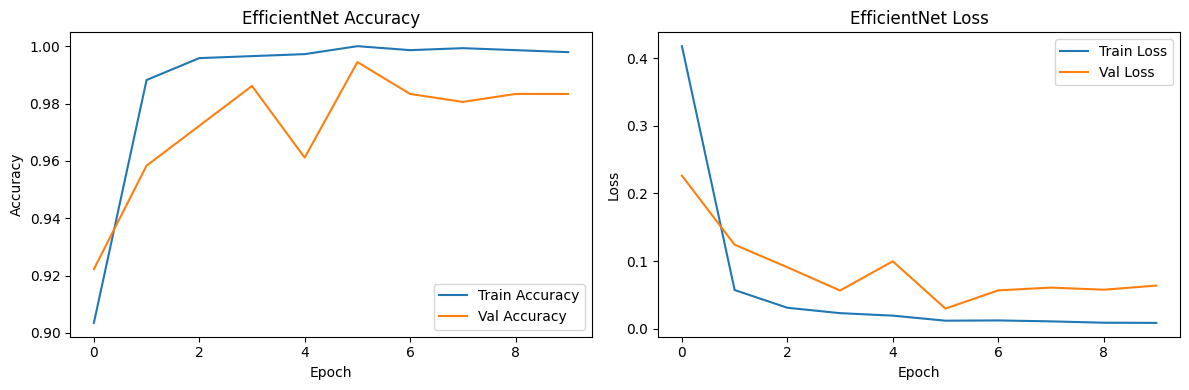

In [ ]:
efficient_model = build_model(EfficientNetB0, "EfficientNet")
train_and_plot(efficient_model, "EfficientNet", epochs=EPOCHS)